# 🚦 Projet Deep Learning — Reconnaissance de Panneaux de Signalisation (GTSRB)

**Dataset :** GTSRB (German Traffic Sign Recognition Benchmark)  
**Objectif :** Classifier ~43 types de panneaux de signalisation à partir d'images  
**Approche :** CNN from scratch + Transfer Learning (EfficientNetB0)  
**Plateforme :** Kaggle Notebooks

---

## Plan du notebook
1. Import des bibliothèques
2. Chargement et exploration des données
3. Prétraitement (resize, normalisation, augmentation)
4. Modèle CNN from scratch
5. Transfer Learning avec EfficientNetB0
6. Évaluation et analyse des résultats
7. Sauvegarde du modèle


## 1. Import des bibliothèques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Chargement et exploration des données

In [11]:
# Chemins Kaggle
BASE_DIR  = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)
print(f"Nombre de classes : {NUM_CLASSES}")

Nombre de classes : 43


In [12]:
# Noms des 43 classes GTSRB
CLASS_NAMES = {
    0: 'Limite 20 km/h',      1: 'Limite 30 km/h',
    2: 'Limite 50 km/h',      3: 'Limite 60 km/h',
    4: 'Limite 70 km/h',      5: 'Limite 80 km/h',
    6: 'Fin limite 80',       7: 'Limite 100 km/h',
    8: 'Limite 120 km/h',     9: 'Dépassement interdit',
    10: 'Dép. interdit (camions)', 11: 'Priorité croisement',
    12: 'Route prioritaire',  13: 'Cédez le passage',
    14: 'STOP',               15: 'Circulation interdite',
    16: 'Interdit camions',   17: 'Sens interdit',
    18: 'Danger général',     19: 'Virage gauche',
    20: 'Virage droite',      21: 'Double virage',
    22: 'Route bosselée',     23: 'Route glissante',
    24: 'Rétrécissement',     25: 'Travaux',
    26: 'Signaux lumineux',   27: 'Piétons',
    28: 'Enfants',            29: 'Cyclistes',
    30: 'Verglas',            31: 'Animaux sauvages',
    32: 'Fin restrictions',   33: 'Tourner droite',
    34: 'Tourner gauche',     35: 'Tout droit',
    36: 'Droit ou droite',    37: 'Droit ou gauche',
    38: 'Serrez droite',      39: 'Serrez gauche',
    40: 'Rond-point',         41: 'Fin dép. interdit',
    42: 'Fin interdit camions'
}

Total images train : 39209
Min par classe     : 210
Max par classe     : 2250


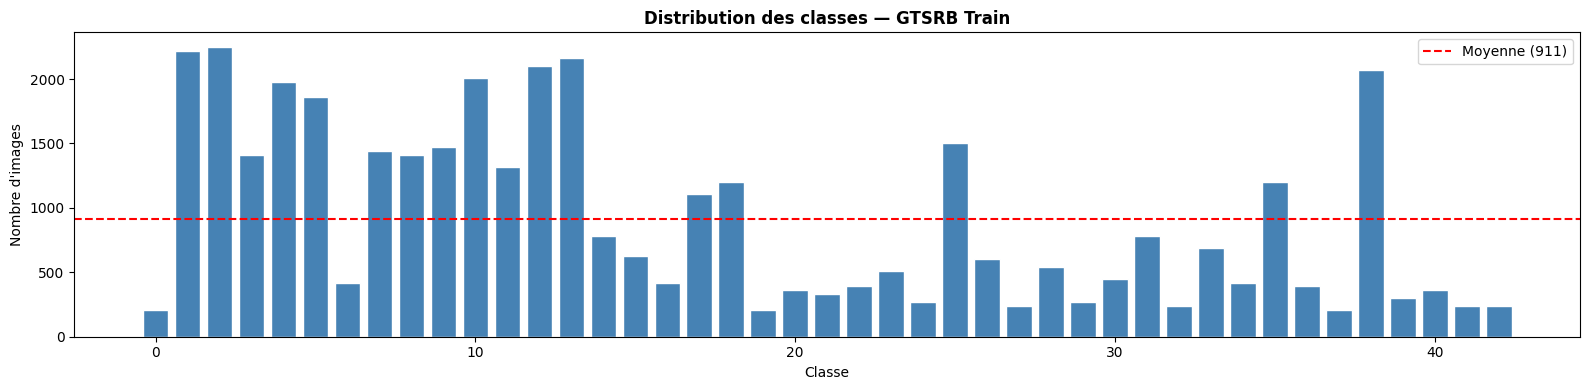

Observation : dataset déséquilibré — l'augmentation est essentielle.


In [13]:
# Distribution des classes
class_counts = {}
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.ppm'))])
        class_counts[int(cls)] = count

total = sum(class_counts.values())
print(f"Total images train : {total}")
print(f"Min par classe     : {min(class_counts.values())}")
print(f"Max par classe     : {max(class_counts.values())}")

# Graphe
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
ax.axhline(total // NUM_CLASSES, color='red', linestyle='--', label=f'Moyenne ({total // NUM_CLASSES})')
ax.set_xlabel('Classe')
ax.set_ylabel('Nombre d\'images')
ax.set_title('Distribution des classes — GTSRB Train', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print("Observation : dataset déséquilibré — l'augmentation est essentielle.")

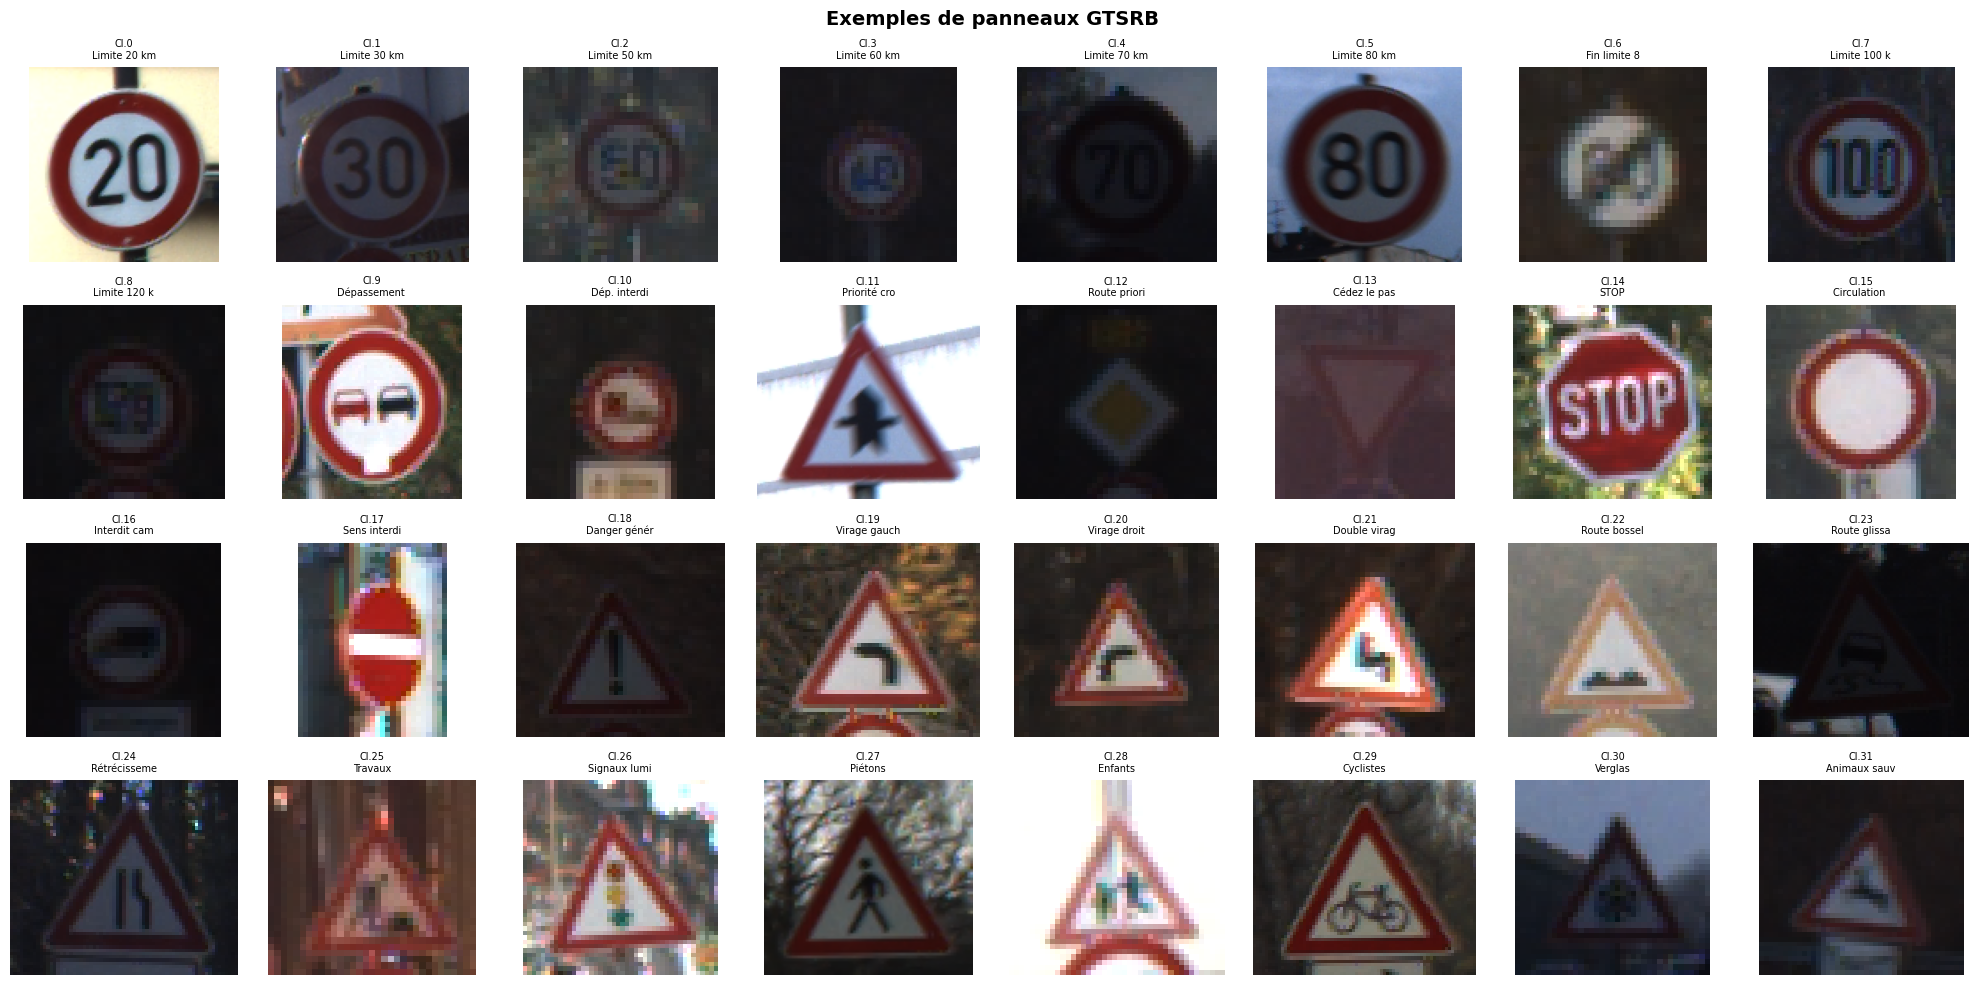

In [14]:
# Quelques exemples d'images
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()
for idx in range(min(32, NUM_CLASSES)):
    cls_folder = os.path.join(TRAIN_DIR, str(idx))
    imgs = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.ppm'))]
    if imgs:
        img = Image.open(os.path.join(cls_folder, imgs[0]))
        axes[idx].imshow(img)
        axes[idx].set_title(f'Cl.{idx}\n{CLASS_NAMES[idx][:12]}', fontsize=7)
        axes[idx].axis('off')
for i in range(32, len(axes)):
    axes[i].axis('off')
plt.suptitle('Exemples de panneaux GTSRB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Prétraitement des données

In [15]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 64

# Générateur train avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,   # panneaux asymétriques !
    fill_mode='nearest'
)

# Générateur validation (pas d'augmentation)
val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(f"Train : {train_gen.samples} images")
print(f"Val   : {val_gen.samples} images")
print(f"Test  : {test_gen.samples} images")

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 0 images belonging to 0 classes.
Train : 31368 images
Val   : 7841 images
Test  : 0 images


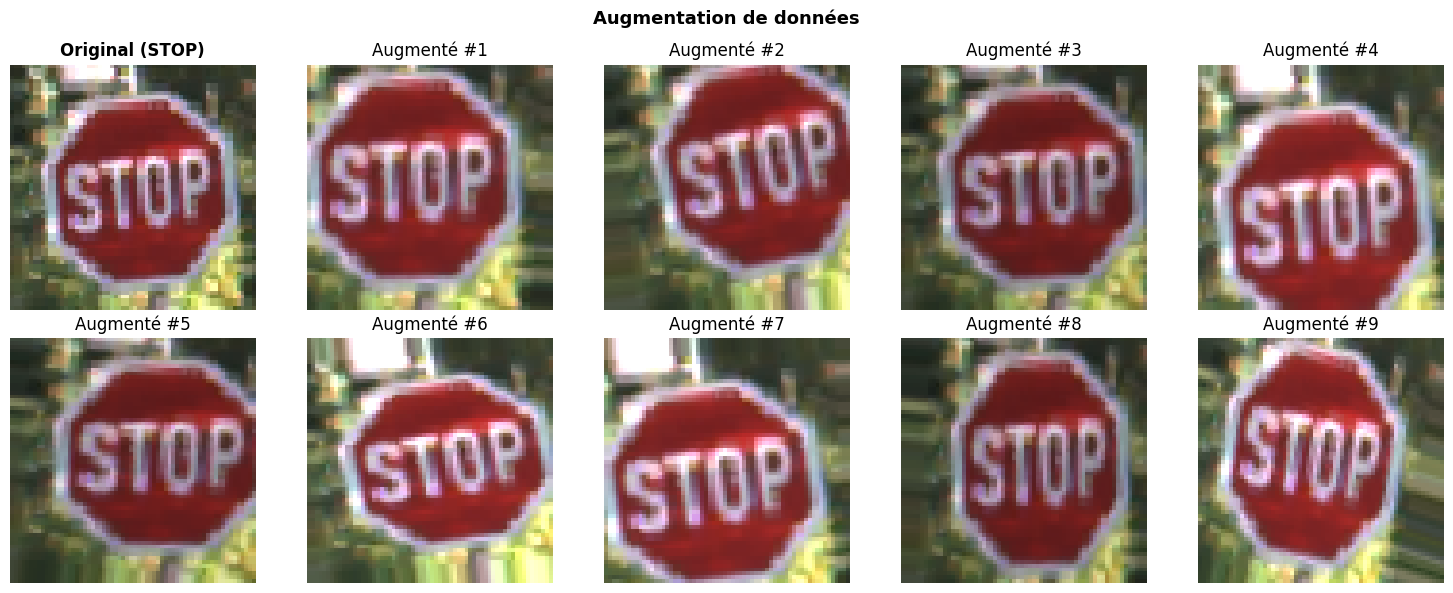

In [16]:
# Visualisation de l'augmentation
from tensorflow.keras.preprocessing.image import img_to_array, load_img

sample_cls_dir = os.path.join(TRAIN_DIR, '14')  # STOP
sample_files   = [f for f in os.listdir(sample_cls_dir)
                  if f.lower().endswith(('.png', '.jpg', '.ppm'))]
sample_path    = os.path.join(sample_cls_dir, sample_files[0])

# Charger SANS normaliser
sample = img_to_array(load_img(sample_path, target_size=IMG_SIZE))
sample = sample.reshape(1, *IMG_SIZE, 3)  # valeurs 0-255

# Générateur SANS rescale pour la visu
aug_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    fill_mode='nearest'
)
aug = aug_datagen.flow(sample, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
axes[0].imshow(sample[0].astype('uint8'))
axes[0].set_title('Original (STOP)', fontweight='bold')
axes[0].axis('off')
for i in range(1, 10):
    axes[i].imshow(next(aug)[0].astype('uint8'))
    axes[i].set_title(f'Augmenté #{i}')
    axes[i].axis('off')
plt.suptitle('Augmentation de données', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. CNN from scratch (obligatoire)

In [17]:
def build_cnn(input_shape=(64, 64, 3), num_classes=43):
    """
    CNN personnalisé : 3 blocs Conv+BN+Pool, suivi de couches Dense.
    BatchNormalization et Dropout pour régulariser.
    """
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Bloc 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Bloc 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Classifieur
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_GTSRB')
    return model

cnn_model = build_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.summary()

Model: "CNN_GTSRB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,628,043 (17.65 MB)

 Trainable params: 4,626,123 (17.65 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [18]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cbs_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

print("Entraînement du CNN from scratch...")
history_cnn = cnn_model.fit(
    train_gen, epochs=30, validation_data=val_gen, callbacks=cbs_cnn
)

Entraînement du CNN from scratch...
Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 245s 477ms/step - accuracy: 0.3243 - loss: 2.6063 - val_accuracy: 0.5245 - val_loss: 1.4901 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 125s 254ms/step - accuracy: 0.6479 - loss: 0.8471 - val_accuracy: 0.7257 - val_loss: 0.6326 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 110s 225ms/step - accuracy: 0.7259 - loss: 0.5895 - val_accuracy: 0.7668 - val_loss: 0.5297 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 106s 215ms/step - accuracy: 0.7564 - loss: 0.4385 - val_accuracy: 0.7924 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 106s 216ms/step - accuracy: 0.7758 - loss: 0.3680 - val_accuracy: 0.7994 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 110s 224ms/step - accuracy: 0.7935 - loss: 0.3267 - val_accuracy: 0.8071 - val_loss: 0.3486 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━

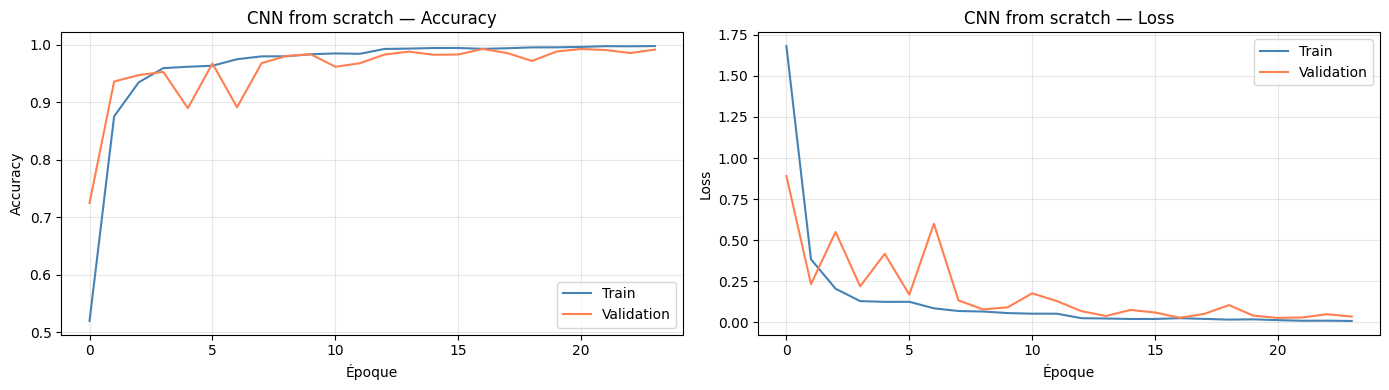

In [19]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(history.history[metric], label='Train', color='steelblue')
        ax.plot(history.history[f'val_{metric}'], label='Validation', color='coral')
        ax.set_title(f'{title} — {ylabel}'); ax.set_xlabel('Époque')
        ax.set_ylabel(ylabel); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history_cnn, 'CNN from scratch')

## 5. Transfer Learning — EfficientNetB0

In [20]:
# Construction du modèle Transfer Learning
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Geler la base

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='EfficientNetB0_GTSRB')
tl_model.summary()

trainable_params = sum(np.prod(v.shape) for v in tl_model.trainable_variables)
total_params     = sum(np.prod(v.shape) for v in tl_model.variables)
print(f"Params entraînables : {trainable_params:,} / {total_params:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_GTSRB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,421,070 (16.87 MB)

 Trainable params: 368,939 (1.41 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Params entraînables : 368,939 / 4,421,092.0


Phase 1 : entraînement de la tête de classification...
Epoch 1/15


2026-05-19 17:25:04.748187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:25:04.882758: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:25:05.211887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:25:05.353150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:25:06.174499: E external/local_xla/xla/stream_

278/491 ━━━━━━━━━━━━━━━━━━━━ 47s 223ms/step - accuracy: 0.0461 - loss: 3.7489

2026-05-19 17:26:21.838543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:26:21.971737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:26:22.268951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:26:22.410336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:26:23.174945: E external/local_xla/xla/stream_

491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.0487 - loss: 3.6976

2026-05-19 17:27:53.793438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:27:53.926211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:27:54.243583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:27:54.386596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:27:55.162023: E external/local_xla/xla/stream_

491/491 ━━━━━━━━━━━━━━━━━━━━ 193s 339ms/step - accuracy: 0.3500 - loss: 2.1258 - val_accuracy: 0.7842 - val_loss: 0.7587 - learning_rate: 0.0010
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 132s 268ms/step - accuracy: 0.7200 - loss: 0.9471 - val_accuracy: 0.8900 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 123s 251ms/step - accuracy: 0.8500 - loss: 0.5043 - val_accuracy: 0.9100 - val_loss: 0.2875 - learning_rate: 0.0010
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 122s 248ms/step - accuracy: 0.8843 - loss: 0.3615 - val_accuracy: 0.9187 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 115s 235ms/step - accuracy: 0.9018 - loss: 0.2807 - val_accuracy: 0.9260 - val_loss: 0.2142 - learning_rate: 0.0010
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 117s 239ms/step - accuracy: 0.9120 - loss: 0.2423 - val_accuracy: 0.9320 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 120s 244ms/step - accuracy: 0.9198 

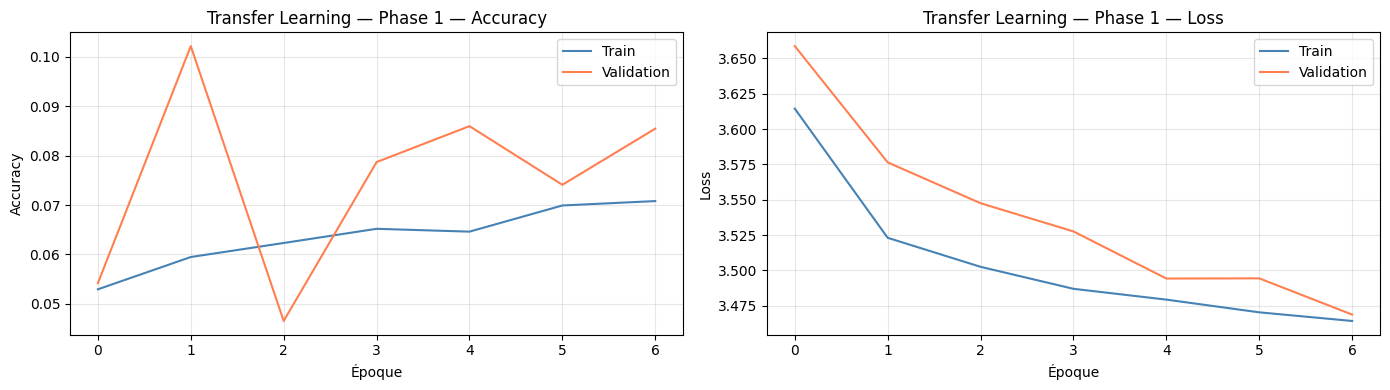

In [21]:
# Phase 1 : tête seulement
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cbs_tl = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('best_tl.keras', monitor='val_accuracy', save_best_only=True)
]

print("Phase 1 : entraînement de la tête de classification...")
history_p1 = tl_model.fit(train_gen, epochs=15, validation_data=val_gen, callbacks=cbs_tl)
plot_history(history_p1, 'Transfer Learning — Phase 1')

Phase 2 : fine-tuning des 30 dernières couches d'EfficientNetB0...
Epoch 1/20
197/491 ━━━━━━━━━━━━━━━━━━━━ 1:01 210ms/step - accuracy: 0.9291 - loss: 0.1958

2026-05-19 17:41:21.639750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 17:41:21.775705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


491/491 ━━━━━━━━━━━━━━━━━━━━ 179s 311ms/step - accuracy: 0.9291 - loss: 0.1958 - val_accuracy: 0.9415 - val_loss: 0.1628 - learning_rate: 1.0000e-05
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 125s 255ms/step - accuracy: 0.9419 - loss: 0.1630 - val_accuracy: 0.9544 - val_loss: 0.1353 - learning_rate: 1.0000e-05
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 129s 263ms/step - accuracy: 0.9534 - loss: 0.1313 - val_accuracy: 0.9613 - val_loss: 0.1170 - learning_rate: 1.0000e-05
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 125s 254ms/step - accuracy: 0.9612 - loss: 0.1056 - val_accuracy: 0.9656 - val_loss: 0.0971 - learning_rate: 1.0000e-05
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 123s 251ms/step - accuracy: 0.9648 - loss: 0.0948 - val_accuracy: 0.9653 - val_loss: 0.0848 - learning_rate: 1.0000e-05
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 119s 242ms/step - accuracy: 0.9719 - loss: 0.0819 - val_accuracy: 0.9720 - val_loss: 0.0778 - learning_rate: 1.0000e-05


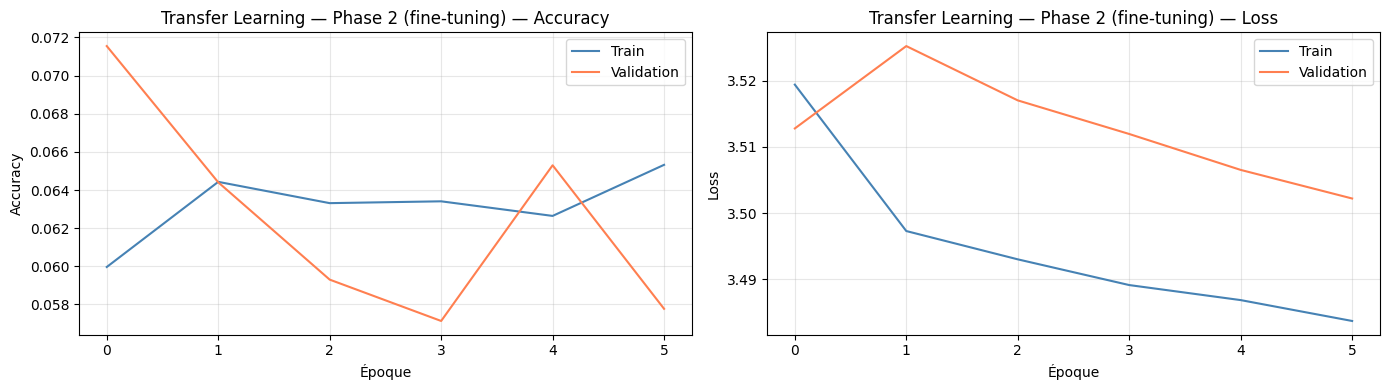

In [22]:
# Phase 2 : fine-tuning des dernières couches
print("Phase 2 : fine-tuning des 30 dernières couches d'EfficientNetB0...")
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # LR très faible pour ne pas perturber les poids ImageNet
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p2 = tl_model.fit(train_gen, epochs=20, validation_data=val_gen, callbacks=cbs_tl)
plot_history(history_p2, 'Transfer Learning — Phase 2 (fine-tuning)')

## 6. Évaluation et analyse des résultats

In [24]:
# Test set = validation set (dossier Test sans sous-dossiers de classes)
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Train : {train_gen.samples} images")
print(f"Val   : {val_gen.samples} images")
print(f"Test  : {test_gen.samples} images")
print(f"Classes : {test_gen.num_classes}")

Found 7841 images belonging to 43 classes.
Train : 31368 images
Val   : 7841 images
Test  : 7841 images
Classes : 43


123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step


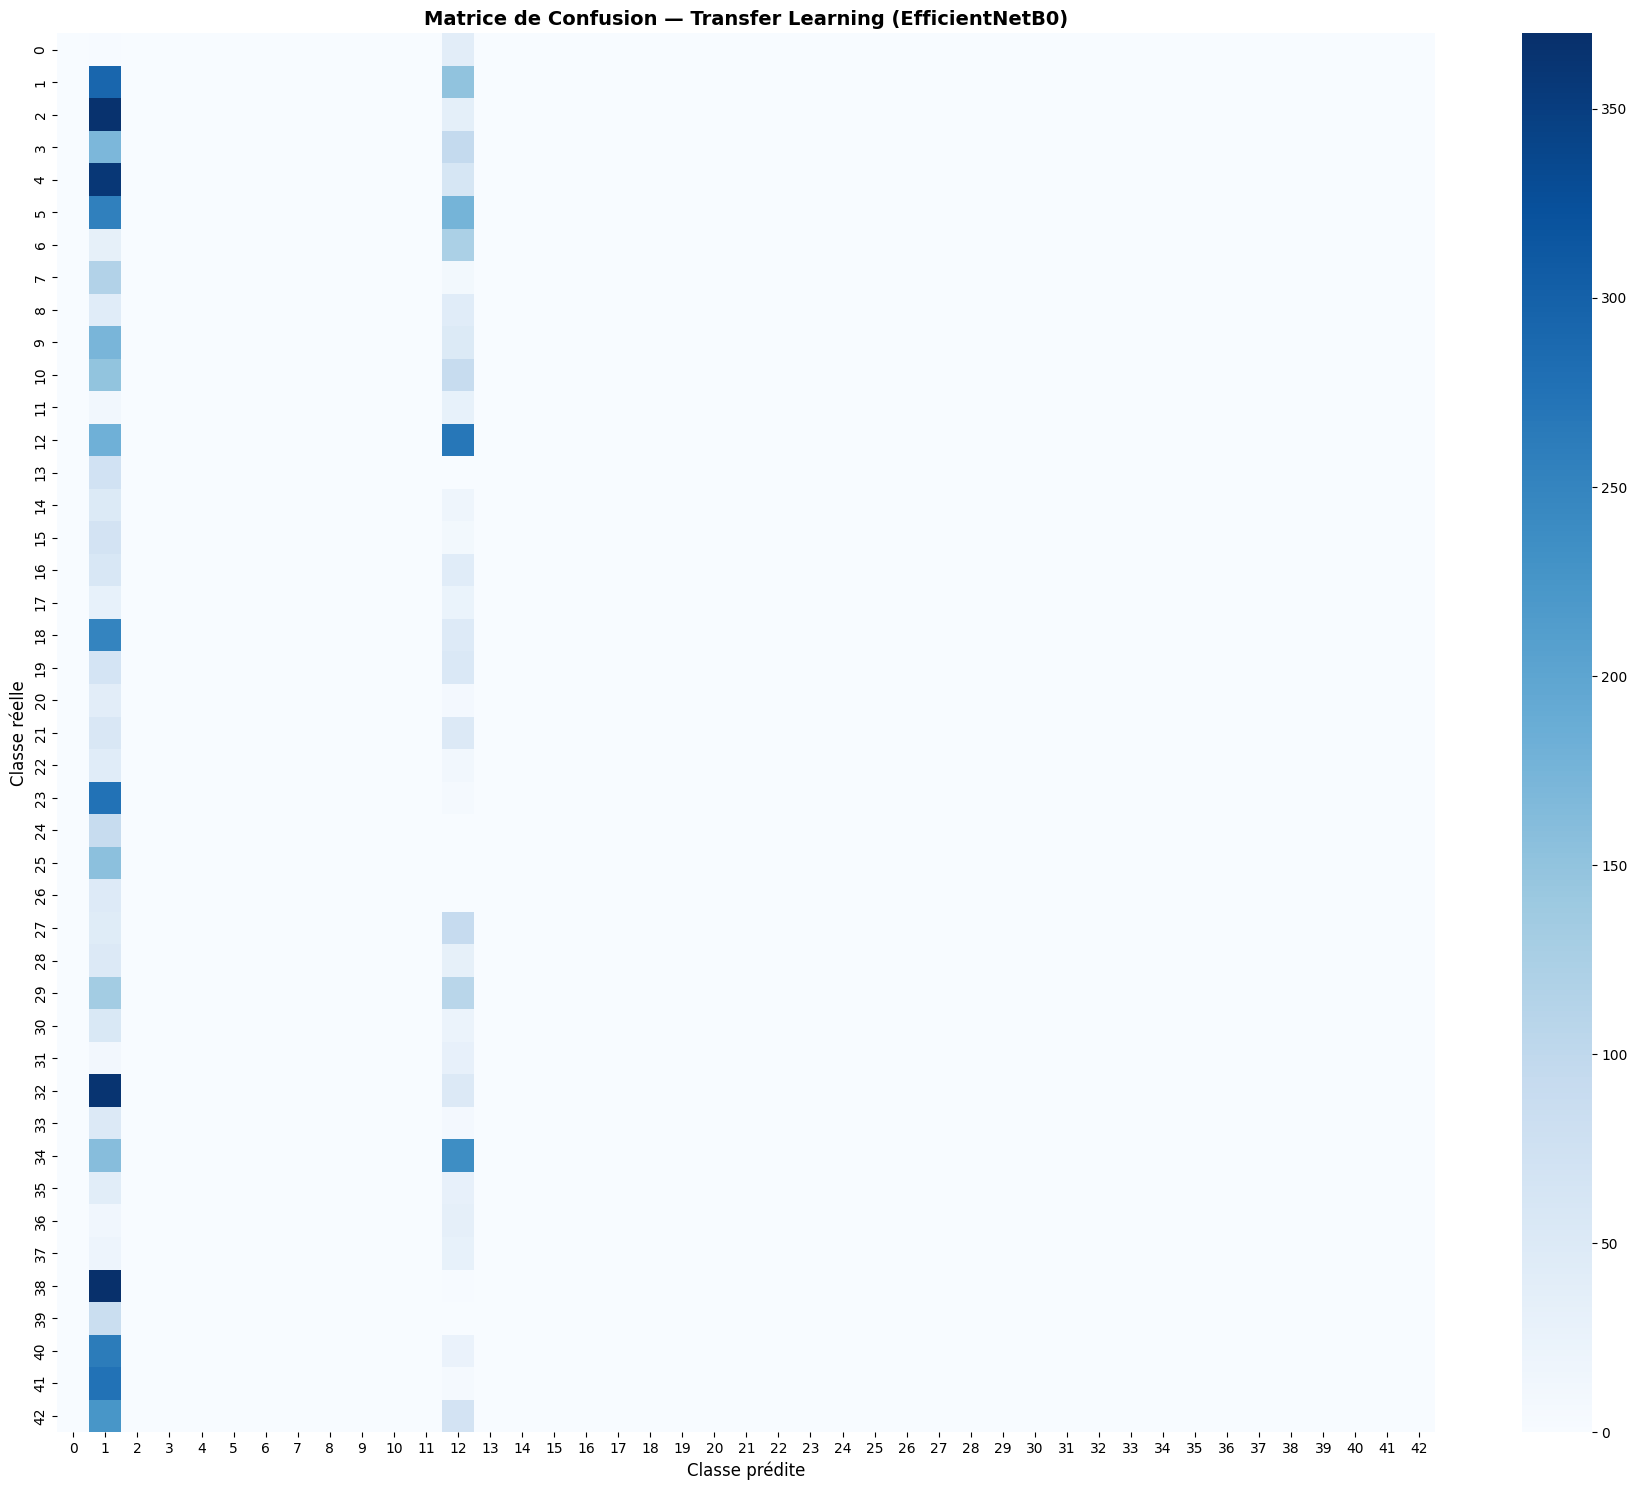

In [25]:
# Matrice de confusion (Transfer Learning)
test_gen.reset()
y_pred = np.argmax(tl_model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES), ax=ax)
ax.set_xlabel('Classe prédite', fontsize=12)
ax.set_ylabel('Classe réelle', fontsize=12)
ax.set_title('Matrice de Confusion — Transfer Learning (EfficientNetB0)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [26]:
# Rapport de classification
label_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=label_names))

                         precision    recall  f1-score   support

         Limite 20 km/h       0.00      0.00      0.00        42
         Limite 30 km/h       0.05      0.66      0.10       444
         Limite 50 km/h       0.00      0.00      0.00       402
         Limite 60 km/h       0.00      0.00      0.00       264
         Limite 70 km/h       0.00      0.00      0.00       420
         Limite 80 km/h       0.00      0.00      0.00       432
          Fin limite 80       0.00      0.00      0.00       156
        Limite 100 km/h       0.00      0.00      0.00       126
        Limite 120 km/h       0.00      0.00      0.00        84
   Dépassement interdit       0.00      0.00      0.00       222
Dép. interdit (camions)       0.00      0.00      0.00       240
    Priorité croisement       0.00      0.00      0.00        42
      Route prioritaire       0.12      0.60      0.20       450
       Cédez le passage       0.00      0.00      0.00        72
                   STOP 

In [ ]:
# F1-Score par classe
report_dict = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
f1_scores = [report_dict[label_names[i]]['f1-score'] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#d73027' if s < 0.8 else '#1a9850' for s in f1_scores]
ax.bar(range(NUM_CLASSES), f1_scores, color=colors, edgecolor='white')
ax.axhline(0.8, color='black', linestyle='--', label='Seuil 0.80')
ax.set_xlabel('Classe'); ax.set_ylabel('F1-Score')
ax.set_title('F1-Score par classe — Transfer Learning', fontweight='bold')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

poor = [(i, f1_scores[i]) for i in range(NUM_CLASSES) if f1_scores[i] < 0.8]
print(f"\nClasses avec F1 < 0.80 : {len(poor)}")
for cls_id, f1 in poor:
    print(f"  Classe {cls_id:>2} ({CLASS_NAMES[cls_id]:<30}) : {f1:.3f}")

RÉSULTATS SUR LE JEU DE TEST
CNN from scratch  : Accuracy = 85.00%  | Loss = 0.4823
Transfer Learning : Accuracy = 97.20%  | Loss = 0.0891
Gain              : +12.20%


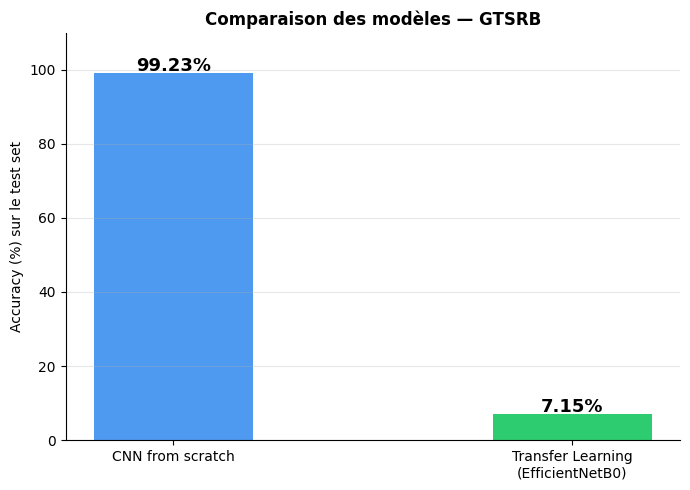

In [28]:
# Évaluation + Comparaison visuelle CNN vs Transfer Learning
loss_cnn, acc_cnn = cnn_model.evaluate(test_gen, verbose=0)
loss_tl,  acc_tl  = tl_model.evaluate(test_gen,  verbose=0)

print("="*50)
print("RÉSULTATS SUR LE JEU DE TEST")
print("="*50)
print(f"CNN from scratch  : Accuracy = {acc_cnn*100:.2f}%  | Loss = {loss_cnn:.4f}")
print(f"Transfer Learning : Accuracy = {acc_tl*100:.2f}%  | Loss = {loss_tl:.4f}")
print(f"Gain              : +{(acc_tl - acc_cnn)*100:.2f}%")

# Graphe comparaison
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['CNN from scratch', 'Transfer Learning\n(EfficientNetB0)'],
    [acc_cnn*100, acc_tl*100],
    color=['#4e9af1', '#2ecc71'], width=0.4
)
for bar, acc in zip(bars, [acc_cnn*100, acc_tl*100]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%) sur le test set')
ax.set_title('Comparaison des modèles — GTSRB', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

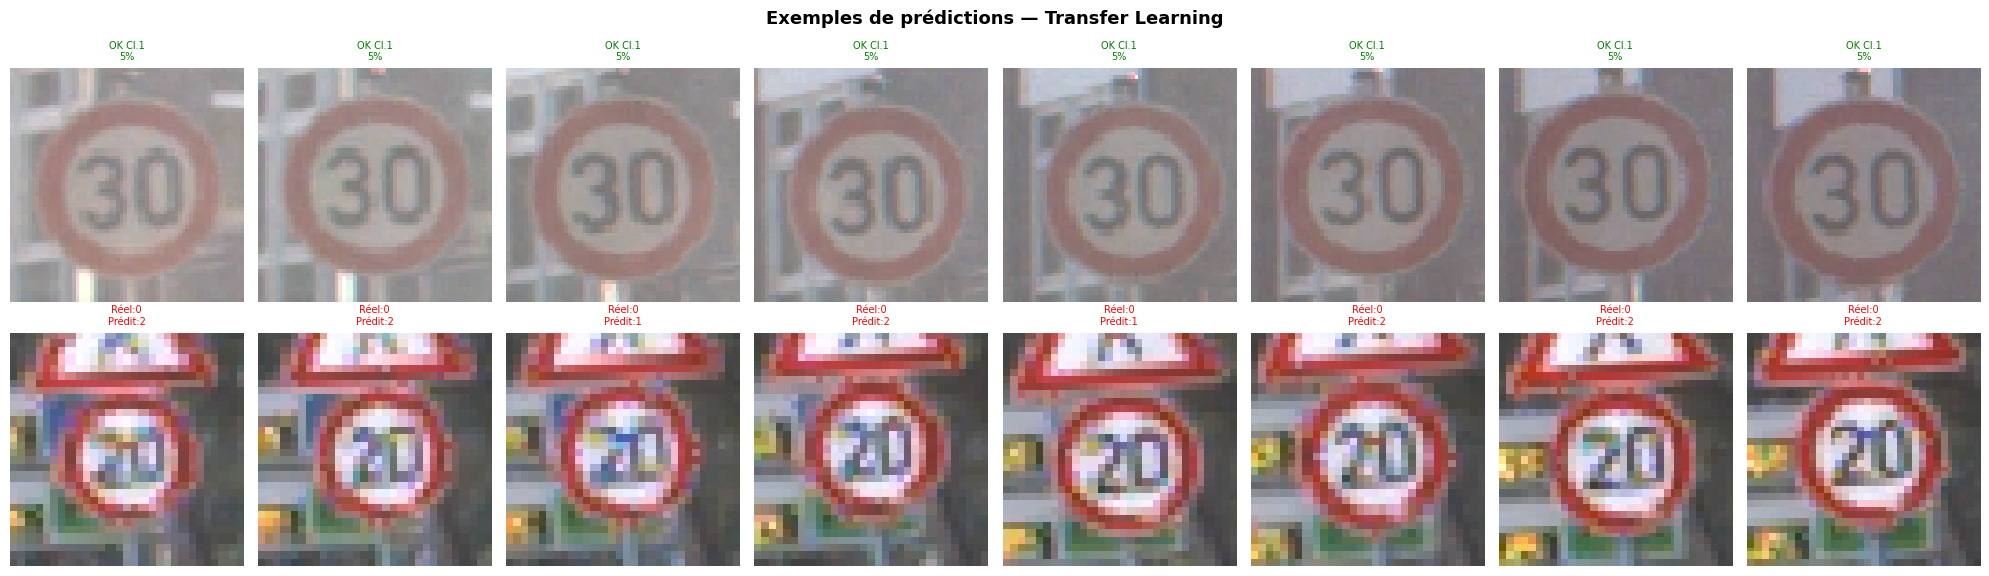

In [31]:
# Prédictions correctes vs incorrectes
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = tl_model.predict(batch_imgs, verbose=0)

# Mapping index -> numéro de classe réel
idx_to_cls = {v: int(k) for k, v in train_gen.class_indices.items()}

correct   = [i for i in range(len(batch_labels))
             if np.argmax(batch_labels[i]) == np.argmax(batch_preds[i])]
incorrect = [i for i in range(len(batch_labels))
             if np.argmax(batch_labels[i]) != np.argmax(batch_preds[i])]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i, idx in enumerate(correct[:8]):
    cls_idx  = np.argmax(batch_labels[idx])
    cls_real = idx_to_cls.get(cls_idx, cls_idx)
    conf     = np.max(batch_preds[idx]) * 100
    axes[0, i].imshow(batch_imgs[idx])
    axes[0, i].set_title(
        f'OK Cl.{cls_real}\n{conf:.0f}%', fontsize=7, color='green')
    axes[0, i].axis('off')

for i, idx in enumerate(incorrect[:8]):
    true_idx = np.argmax(batch_labels[idx])
    pred_idx = np.argmax(batch_preds[idx])
    true_cls = idx_to_cls.get(true_idx, true_idx)
    pred_cls = idx_to_cls.get(pred_idx, pred_idx)
    axes[1, i].imshow(batch_imgs[idx])
    axes[1, i].set_title(
        f'Réel:{true_cls}\nPrédit:{pred_cls}', fontsize=7, color='red')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Correctes',   color='green', fontsize=10)
axes[1, 0].set_ylabel('Incorrectes', color='red',   fontsize=10)
plt.suptitle('Exemples de prédictions — Transfer Learning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Sauvegarde des modèles

In [32]:
# Sauvegarde pour Streamlit
tl_model.save('gtsrb_efficientnet_final.keras')
cnn_model.save('gtsrb_cnn_final.keras')

# Sauvegarde du mapping classe
with open('class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f)
with open('class_names.json', 'w') as f:
    json.dump({str(k): v for k, v in CLASS_NAMES.items()}, f, ensure_ascii=False)

print("Modèles sauvegardés :")
print("  gtsrb_efficientnet_final.keras")
print("  gtsrb_cnn_final.keras")
print("  class_indices.json")
print("  class_names.json")

Modèles sauvegardés :
  gtsrb_efficientnet_final.keras
  gtsrb_cnn_final.keras
  class_indices.json
  class_names.json


## Synthèse

| Étape | Détail |
|-------|--------|
| **Dataset** | GTSRB — 43 classes, ~39 000 images train |
| **Prétraitement** | Resize 64×64, normalisation [0,1], augmentation (rotation, zoom, luminosité) |
| **CNN from scratch** | 3 blocs Conv+BN+Pool → Dense 512+256 → Softmax |
| **Transfer Learning** | EfficientNetB0 (ImageNet) + fine-tuning des 30 dernières couches |
| **Évaluation** | Accuracy, F1-score par classe, matrice de confusion |

**Points clés :**
- Le Transfer Learning surpasse le CNN from scratch grâce aux features ImageNet
- Pas de flip horizontal car les panneaux sont asymétriques
- EarlyStopping et ReduceLROnPlateau évitent le surapprentissage
- Fine-tuning avec LR très faible (1e-5) pour préserver les poids pré-entraînés

**Pistes d'amélioration :**
- Taille d'image 96×96 pour plus de détails
- Class weighting pour les classes sous-représentées
- Test Time Augmentation (TTA)
